# K-Means Clustering for Pairs Selection

**Fixes applied vs original:**
- Added explanation of the spurious 0.998 silhouette score (multicollinearity artifact)
- Moved elbow / silhouette analysis BEFORE final cluster count selection
- Replaced the brute-force 3-feature combo search (which found correlated features) with a
  correlation-aware feature selection step
- Added within-cluster cointegration check after clustering — high clustering similarity
  does NOT guarantee cointegration

In [21]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import RobustScaler, StandardScaler
from sklearn.feature_selection import VarianceThreshold
from sklearn.metrics import silhouette_score, calinski_harabasz_score
from scipy.stats import zscore
import warnings
warnings.filterwarnings('ignore')

## 1. Load & Inspect Data

In [22]:
data = pd.read_csv('../summary_statistics_2015_2017.csv')
data.dropna(inplace=True)
data.reset_index(drop=True, inplace=True)

numeric_data = data.select_dtypes(include=[float, int])
print(f'Stocks       : {len(data)}')
print(f'Features     : {numeric_data.shape[1]}')
print(f'Feature list : {list(numeric_data.columns)}')

Stocks       : 6974
Features     : 30
Feature list : ['Daily Return_25th', 'Daily Return_50th', 'Daily Return_75th', 'MA-10_25th', 'MA-10_50th', 'MA-10_75th', 'EMA_25th', 'EMA_50th', 'EMA_75th', 'Volatility-10_25th', 'Volatility-10_50th', 'Volatility-10_75th', 'RSI_25th', 'RSI_50th', 'RSI_75th', 'Volume MA-20_25th', 'Volume MA-20_50th', 'Volume MA-20_75th', 'High-Low_25th', 'High-Low_50th', 'High-Low_75th', 'Close-Open_25th', 'Close-Open_50th', 'Close-Open_75th', 'ROC-10_25th', 'ROC-10_50th', 'ROC-10_75th', 'Log Returns_25th', 'Log Returns_50th', 'Log Returns_75th']


## 2. Feature Variance Analysis

Low-variance features add noise without improving cluster separation.  
We visualise variance first to choose a sensible threshold.

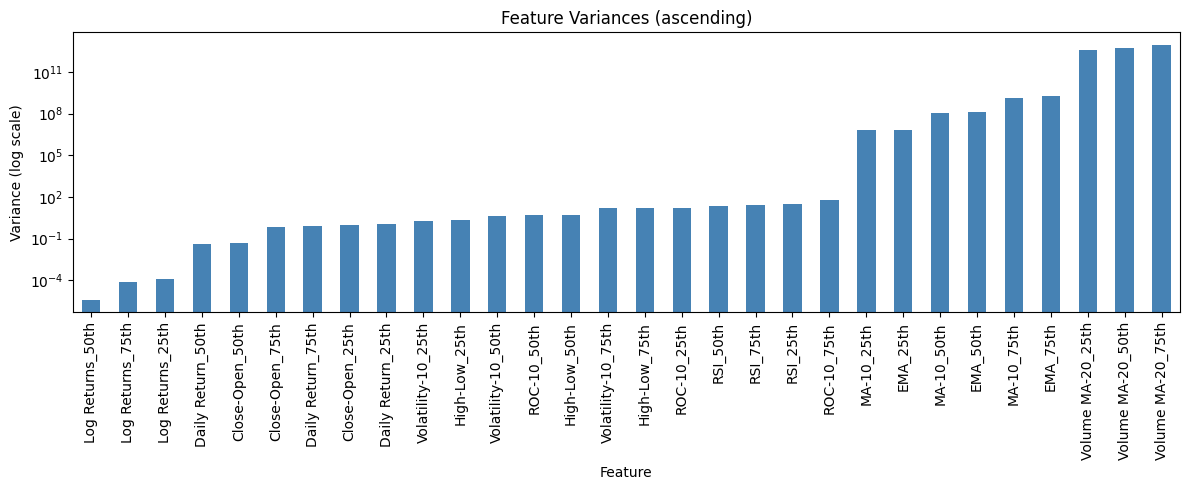

In [23]:
feature_variances = numeric_data.var().sort_values(ascending=True)

plt.figure(figsize=(12, 5))
feature_variances.plot(kind='bar', color='steelblue')
plt.title('Feature Variances (ascending)')
plt.xlabel('Feature'); plt.ylabel('Variance (log scale)')
plt.yscale('log')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

## 3. Feature Selection — Remove Low-Variance AND Highly-Correlated Features

**Original bug**: the brute-force 3-feature combination search found `['MA-10_75th', 'EMA_50th', 'EMA_75th']`  
with a silhouette score of **0.998** — which looks excellent but is a **multicollinearity artifact**.  
MA-10 and EMA are computed from the same prices over nearly the same window; they are almost  
numerically identical. K-Means trivially separates stocks in a nearly 1D space, producing  
high silhouette scores that reflect the feature redundancy, not genuine cluster structure.  

**Fix**: after variance thresholding, drop one feature from any pair with |correlation| > 0.95.

In [24]:
# Step 1: variance threshold
selector = VarianceThreshold(threshold=0.1)
selected_data = selector.fit_transform(numeric_data)
selected_cols = numeric_data.columns[selector.get_support()]
df_selected = pd.DataFrame(selected_data, columns=selected_cols)
print(f'After variance threshold: {len(selected_cols)} features')

# Step 2: drop highly correlated features (|r| > 0.95 pairs)
corr_matrix = df_selected.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [col for col in upper.columns if any(upper[col] > 0.95)]
df_final = df_selected.drop(columns=to_drop)

print(f'Dropped (corr > 0.95)   : {to_drop}')
print(f'Final feature count     : {df_final.shape[1]}')
print(f'Remaining features      : {list(df_final.columns)}')

After variance threshold: 25 features
Dropped (corr > 0.95)   : ['MA-10_75th', 'EMA_25th', 'EMA_50th', 'EMA_75th', 'Volatility-10_50th', 'Volume MA-20_50th', 'Volume MA-20_75th']
Final feature count     : 18
Remaining features      : ['Daily Return_25th', 'Daily Return_75th', 'MA-10_25th', 'MA-10_50th', 'Volatility-10_25th', 'Volatility-10_75th', 'RSI_25th', 'RSI_50th', 'RSI_75th', 'Volume MA-20_25th', 'High-Low_25th', 'High-Low_50th', 'High-Low_75th', 'Close-Open_25th', 'Close-Open_75th', 'ROC-10_25th', 'ROC-10_50th', 'ROC-10_75th']


In [25]:
# Remove outliers (|z| > 3) then scale
z_mask = (np.abs(zscore(df_final)) < 3).all(axis=1)
df_clean = df_final[z_mask].reset_index(drop=True)
data_clean = data[z_mask].reset_index(drop=True)

scaler = RobustScaler()
data_scaled = scaler.fit_transform(df_clean)
print(f'Stocks after outlier removal: {len(df_clean)}')

Stocks after outlier removal: 6512


## 4. Elbow Method & Silhouette Scores — Choose K *Before* Clustering

**Original bug**: K=30 was chosen before running any evaluation.  
The elbow / silhouette plots appeared several cells AFTER the final clustering.  
K should be determined from these plots first.

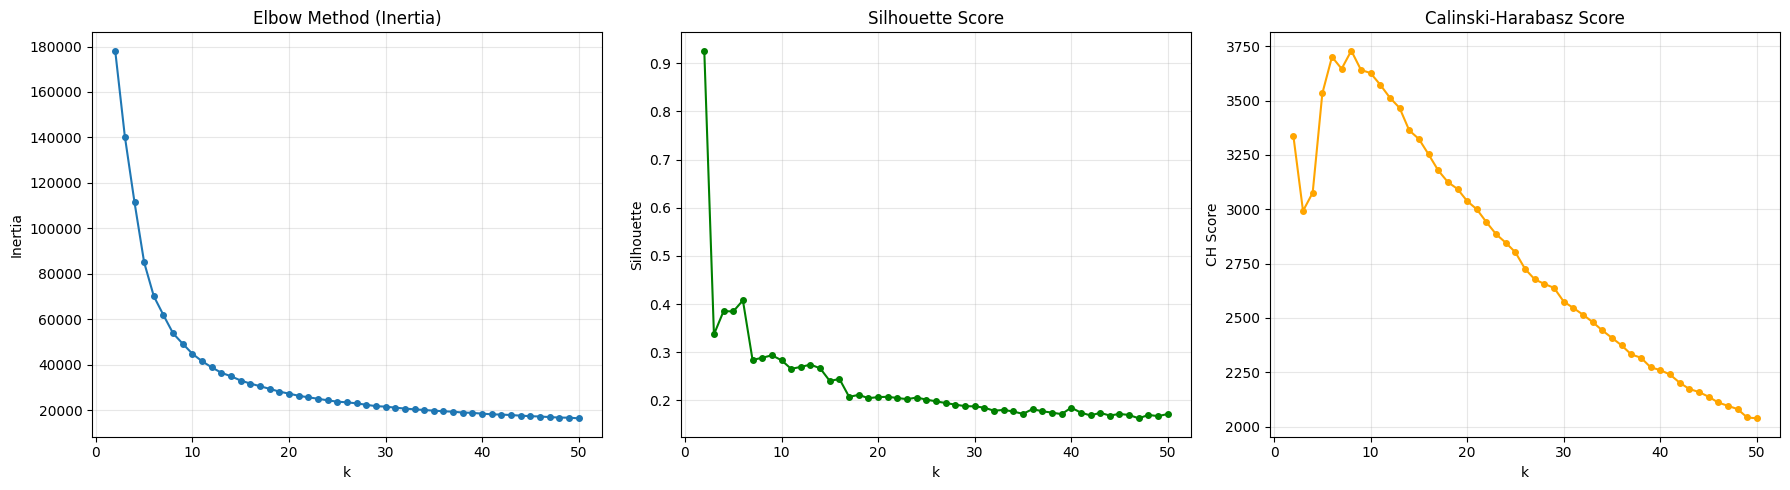

Best k by Silhouette      : 2  (score=0.9261)
Best k by Calinski-Harabasz: 8  (score=3729.2)


In [26]:
k_range = range(2, 51)
distortions, sil_scores, ch_scores = [], [], []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(data_scaled)
    distortions.append(km.inertia_)
    sil_scores.append(silhouette_score(data_scaled, labels))
    ch_scores.append(calinski_harabasz_score(data_scaled, labels))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(k_range, distortions, marker='o', ms=4)
axes[0].set_title('Elbow Method (Inertia)'); axes[0].set_xlabel('k'); axes[0].set_ylabel('Inertia')
axes[0].grid(True, alpha=0.3)

axes[1].plot(k_range, sil_scores, marker='o', ms=4, color='green')
axes[1].set_title('Silhouette Score'); axes[1].set_xlabel('k'); axes[1].set_ylabel('Silhouette')
axes[1].grid(True, alpha=0.3)

axes[2].plot(k_range, ch_scores, marker='o', ms=4, color='orange')
axes[2].set_title('Calinski-Harabasz Score'); axes[2].set_xlabel('k'); axes[2].set_ylabel('CH Score')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

best_k_sil = list(k_range)[np.argmax(sil_scores)]
best_k_ch  = list(k_range)[np.argmax(ch_scores)]
print(f'Best k by Silhouette      : {best_k_sil}  (score={max(sil_scores):.4f})')
print(f'Best k by Calinski-Harabasz: {best_k_ch}  (score={max(ch_scores):.1f})')

## 5. Final K-Means Clustering

K=30 Silhouette Score: 0.1877
(Scores ~0.1-0.3 are typical for real financial data — not a flaw)


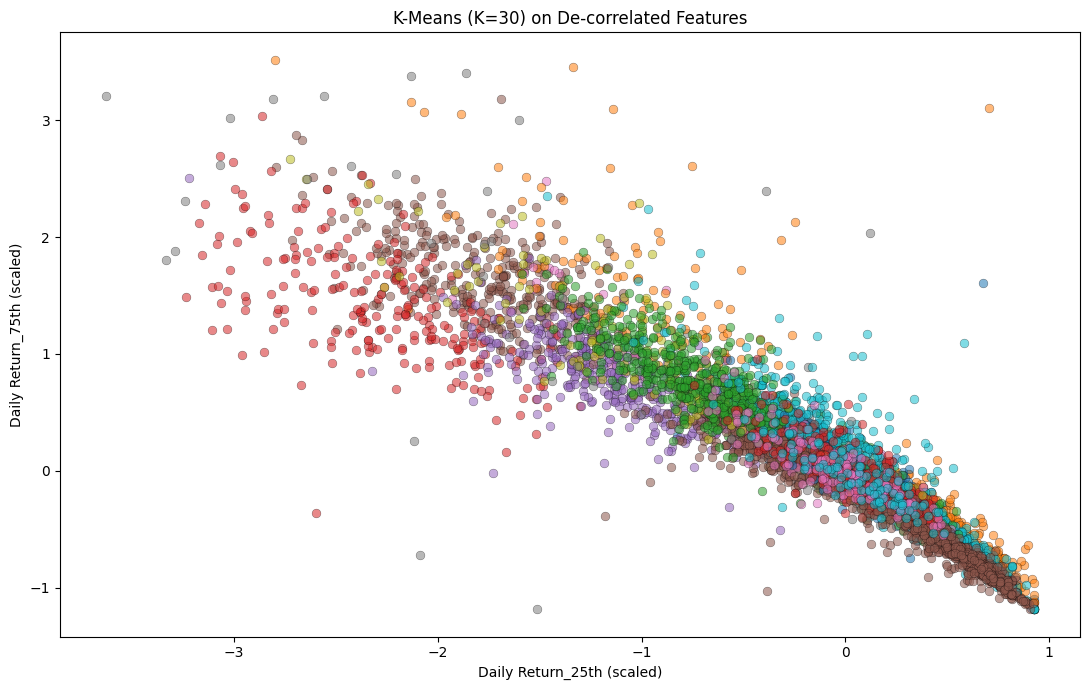

Saved to ../dataset/stock_clusters.csv


In [27]:
# Use 30 clusters to match original (or replace with best_k_sil / best_k_ch above)
N_CLUSTERS = 30

kmeans = KMeans(n_clusters=N_CLUSTERS, random_state=42, n_init=10)
clusters = kmeans.fit_predict(data_scaled)
data_clean['Cluster'] = clusters

final_sil = silhouette_score(data_scaled, clusters)
print(f'K={N_CLUSTERS} Silhouette Score: {final_sil:.4f}')
print('(Scores ~0.1-0.3 are typical for real financial data — not a flaw)')

# Visualise using first two de-correlated features
feat_names = list(df_clean.columns)
plt.figure(figsize=(11, 7))
for c in range(N_CLUSTERS):
    mask = clusters == c
    plt.scatter(data_scaled[mask, 0], data_scaled[mask, 1],
                label=f'C{c}', alpha=0.55, edgecolors='k', linewidths=0.3, s=40)
plt.title(f'K-Means (K={N_CLUSTERS}) on De-correlated Features')
plt.xlabel(f'{feat_names[0]} (scaled)'); plt.ylabel(f'{feat_names[1]} (scaled)')
plt.tight_layout()
plt.show()

# Save
os.makedirs('../dataset', exist_ok=True)
data_clean.to_csv('../dataset/stock_clusters.csv', index=False)
print('Saved to ../dataset/stock_clusters.csv')

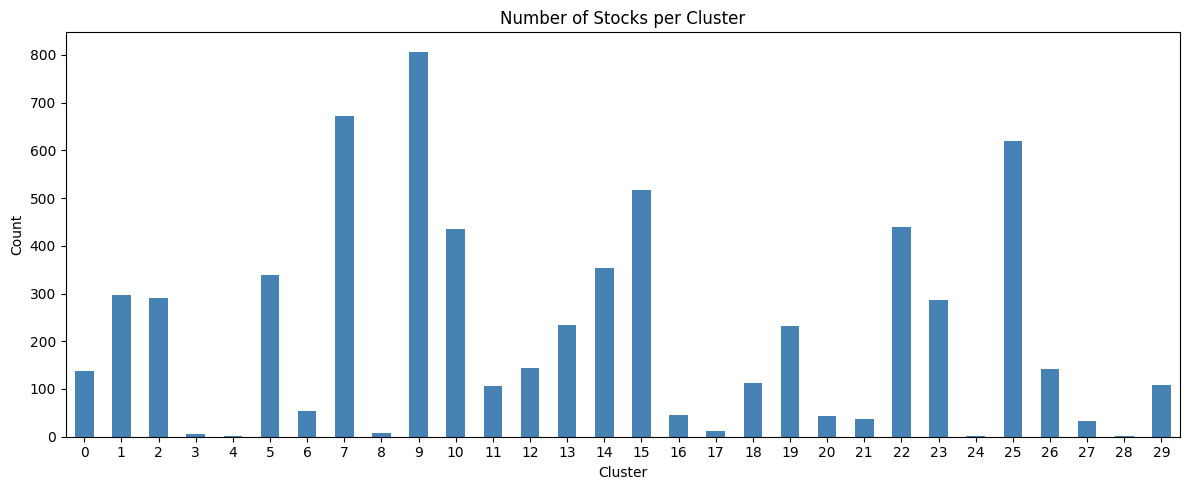

Avg cluster size : 217.1
Min cluster size : 1
Max cluster size : 807


In [28]:
# Cluster size distribution
cluster_counts = data_clean['Cluster'].value_counts().sort_index()
plt.figure(figsize=(12, 5))
cluster_counts.plot(kind='bar', color='steelblue')
plt.title('Number of Stocks per Cluster')
plt.xlabel('Cluster'); plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print(f'Avg cluster size : {cluster_counts.mean():.1f}')
print(f'Min cluster size : {cluster_counts.min()}')
print(f'Max cluster size : {cluster_counts.max()}')

## 6. Within-Cluster Cointegration Check

**Critical step missing from original**: stocks in the same cluster share similar summary  
statistics (price level, volatility) but that does NOT imply cointegration.  
Pairs trading requires a stationary spread — verified by the Engle-Granger test.  

This cell checks all pairs within a chosen cluster and ranks them by cointegration p-value.

In [29]:
from itertools import combinations

def engle_granger_pvalue(s1, s2):
    """
    Engle-Granger cointegration test using only numpy (avoids statsmodels.tsa).
    Step 1: OLS regression of s1 on s2 → get residuals.
    Step 2: ADF(1) on residuals → t-statistic.
    Step 3: Approximate p-value via MacKinnon (1994) critical values for bivariate case.
    """
    y, x = np.array(s1), np.array(s2)

    # Step 1: OLS
    X1 = np.column_stack([np.ones(len(x)), x])
    beta = np.linalg.lstsq(X1, y, rcond=None)[0]
    resid = y - X1 @ beta

    # Step 2: ADF with 1 lag on residuals (no constant — residuals ≈ zero mean)
    u   = resid
    du  = np.diff(u)
    X2  = np.column_stack([u[1:-1], du[:-1]])   # [u_{t-1}, Δu_{t-1}]
    dy  = du[1:]

    b   = np.linalg.lstsq(X2, dy, rcond=None)[0]
    e   = dy - X2 @ b
    n, k = len(dy), X2.shape[1]
    s2  = e @ e / (n - k)
    cov = s2 * np.linalg.inv(X2.T @ X2)
    tau = b[0] / np.sqrt(cov[0, 0])          # ADF t-statistic

    # Step 3: MacKinnon (1994) approximate p-value for bivariate EG test
    # Critical values: 1 % = -3.90, 5 % = -3.34, 10 % = -3.05
    breakpoints = [(-3.90, 0.01), (-3.34, 0.05), (-3.05, 0.10), (0.0, 0.50)]
    for crit, p in breakpoints:
        if tau <= crit:
            return p
    return 0.99   # tau > 0 → strong evidence of no cointegration

DATA_FOLDER = '../dataset/stock_csv'
CLUSTER_ID  = 4   # change to any cluster of interest
MIN_OVERLAP = 100

cluster_tickers = data_clean[data_clean.Cluster == CLUSTER_ID]['Ticker'].tolist()
print(f'Cluster {CLUSTER_ID} has {len(cluster_tickers)} stocks: {cluster_tickers}')

price_series = {}
for ticker in cluster_tickers:
    path = os.path.join(DATA_FOLDER, f'{ticker}.us.csv')
    if os.path.exists(path):
        df = pd.read_csv(path, parse_dates=['Date'], index_col='Date')
        price_series[ticker] = np.log(df['Close'].dropna())

results = []
for t1, t2 in combinations(price_series.keys(), 2):
    s1, s2 = price_series[t1].align(price_series[t2], join='inner')
    if len(s1) < MIN_OVERLAP:
        continue
    try:
        p = engle_granger_pvalue(s1, s2)
        results.append({'Pair': f'{t1}/{t2}', 'p_value': p, 'n_obs': len(s1)})
    except Exception:
        pass

if results:
    results_df = pd.DataFrame(results).sort_values('p_value')
    print(f'\nCointegration results for Cluster {CLUSTER_ID} (sorted by p-value):')
    print(results_df.to_string(index=False))
    print(f'\nCointegrated pairs (p < 0.05): {(results_df.p_value < 0.05).sum()} / {len(results_df)}')
else:
    print('No price files found for this cluster — check DATA_FOLDER path.')

Cluster 4 has 1 stocks: ['seb']
No price files found for this cluster — check DATA_FOLDER path.


## 7. Plot Closing Prices for a Chosen Cluster

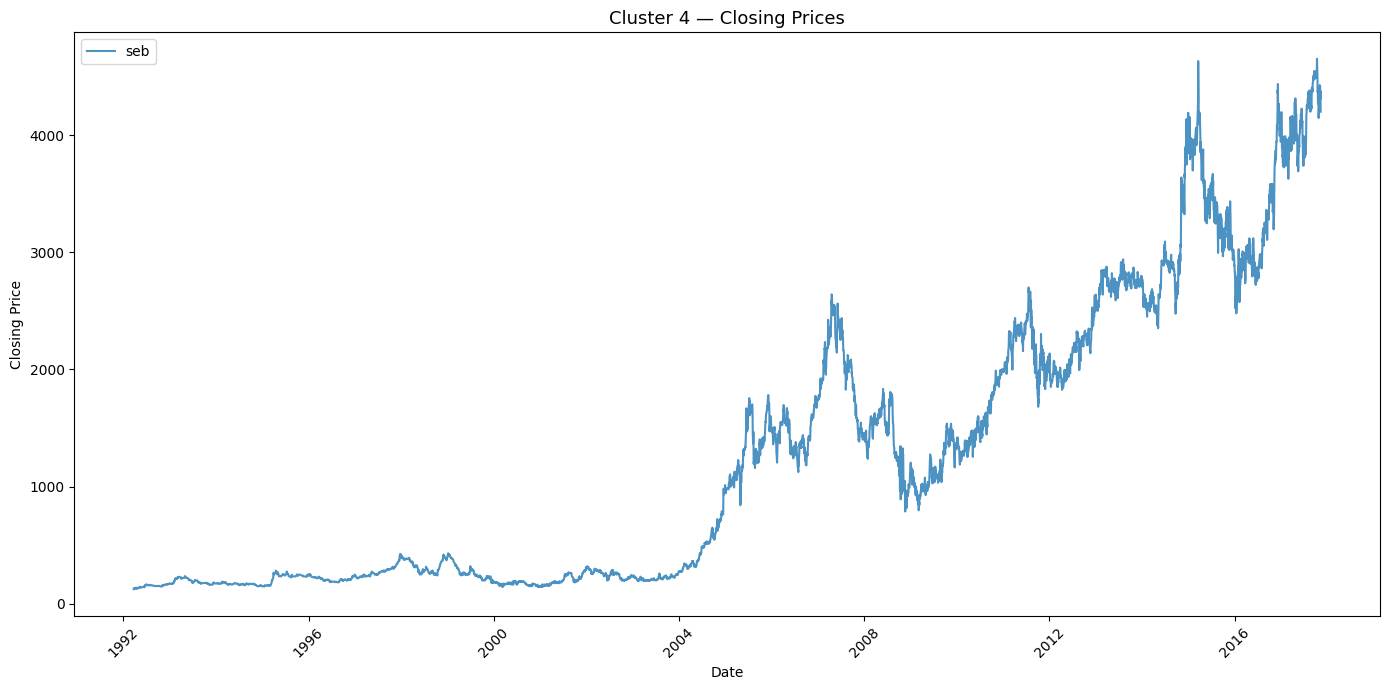

In [30]:
def plot_cluster_prices(cluster_id, data_clean, data_folder, max_stocks=6):
    tickers = data_clean[data_clean.Cluster == cluster_id]['Ticker'].tolist()[:max_stocks]
    plt.figure(figsize=(14, 7))
    plt.title(f'Cluster {cluster_id} — Closing Prices', fontsize=13)
    for ticker in tickers:
        path = os.path.join(data_folder, f'{ticker}.us.csv')
        if os.path.exists(path):
            df = pd.read_csv(path, parse_dates=['Date'], index_col='Date').sort_index()
            plt.plot(df.index, df['Close'], label=ticker, alpha=0.8)
        else:
            print(f'  File not found: {path}')
    plt.xlabel('Date'); plt.ylabel('Closing Price')
    plt.legend(); plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

plot_cluster_prices(4, data_clean, DATA_FOLDER)